# 🛰 Spaceborne lidar for vegetation assessment🌲

# Howdy & Welcome to the LASERS Lab ICESat-2 / GEDI Canopy Height Model tutorial!
FYI, this notebook is intended to be run within Google Colab; other environments may require minor alterations.

# **Please cite** with this DOI: https://doi.org/10.5281/zenodo.19099501

# helpful docs  

* [ICESat-2]( https://www.earthdata.nasa.gov/data/platforms/space-based-platforms/icesat-2)

 * [ATL08 ATBD](https://icesat-2.gsfc.nasa.gov/sites/default/files/page_files/ICESat2_ATL08_ATBD_r006.pdf)

 * [SlideRule: ICESat-2 Module](https://slideruleearth.io/rtd/user_guide/icesat2.html)

 * [SlideRule: ICESat-2 Module: atl08p parameters](https://slideruleearth.io/web/rtd/api_reference/icesat2.html#atl08p)


* [GEDI](https://www.earthdata.nasa.gov/data/projects/gedi)

 * [GEDI ATBD](https://lpdaac.usgs.gov/documents/581/GEDI_WF_ATBD_v1.0.pdf)

 * [GEDI L2A Product Data Dictionary](https://lpdaac.usgs.gov/documents/982/gedi_l2a_dictionary_P003_v2.html)

 * [GEDI Level 2 User Guide](https://lpdaac.usgs.gov/documents/986/GEDI02_UserGuide_V2.pdf)

 * [GEDI02_A v002 (moving soon)](https://lpdaac.usgs.gov/products/gedi02_av002/)

 * [SlideRule: GEDI Module](https://slideruleearth.io/rtd/user_guide/gedi.html)

 * [SlideRule: GEDI Module: gedi02ap parameters](https://slideruleearth.io/web/rtd/api_reference/gedi.html#gedi02ap)

 * [Example GEDI notebook](https://github.com/nasa/GEDI-Data-Resources/blob/main/python/tutorials/GEDI_L2A_V2_Tutorial.ipynb)

# Set up the notebook

In [ ]:
# Install necessary libraries (this part '--quiet > /dev/null 2>&1' keeps it clean)
!pip install sliderule --quiet > /dev/null 2>&1
!pip install rasterio --quiet > /dev/null 2>&1
!pip install rasterstats --quiet > /dev/null 2>&1

In [ ]:
# ===============================
# Standard Library
# ===============================
import os
import math
import random
import itertools
import re
import shutil
import glob
import pickle
import time
import warnings
from datetime import datetime

# ===============================
# Scientific Computing & Data Handling
# ===============================
import numpy as np
import pandas as pd

# ===============================
# Statistical Modeling & Machine Learning
# ===============================
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    GridSearchCV
)
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    mean_squared_error, mean_absolute_error, r2_score,
    confusion_matrix, ConfusionMatrixDisplay
)
import statsmodels.api as sm
from scipy import stats
import joblib

# ===============================
# Visualization
# ===============================
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from matplotlib.ticker import MultipleLocator

# ===============================
# Geospatial Libraries
# ===============================
import rasterio
from rasterio.merge import merge
from rasterstats import point_query
import geopandas as gpd
from shapely.geometry import Point
import folium

# ===============================
# Earth Engine & Remote Sensing
# ===============================
import ee
import ee.mapclient
import geemap

# ===============================
# Sliderule & GEDI
# ===============================
from sliderule import sliderule, icesat2, gedi
# import earthaccess

# ===============================
# Image Processing
# ===============================
import cv2
from google.colab.patches import cv2_imshow

# ===============================
# Google Colab Integration
# ===============================
from google.colab import drive

# ===============================
# Initialize External Services
# ===============================
sliderule.init("slideruleearth.io")
gedi.init()

We will now set the project paths, create directories, and allow permissions. To proceed in this notebook, you **MUST** allow access to your Google Drive files (Allow Access > Continue > Continue).

In [ ]:
# Set project path
proj_path = '/content/drive/MyDrive/Colab Notebooks/'

ee_exports = '/content/drive/MyDrive/GEE_Exports_temp/'
output = proj_path + 'output/'

# Mount the drive
if os.path.isdir('/content/drive/My Drive'):
    print("Drive is already mounted!")
else:
    drive.mount('/content/drive')
    print("Drive is now mounted!")

Mounted at /content/drive
Drive is now mounted!


In [ ]:
# Create folder structure
def create_folder(folder_path):
  if os.path.exists(folder_path):
    print(f"'{folder_path}'\n already exists\n")
  else:
    os.makedirs(folder_path)
    print(f"'{folder_path}'\n created successfully\n")

# Create folders
create_folder(output)

'/content/drive/MyDrive/Colab Notebooks/output/'
 already exists



In [ ]:
# Check contents of project path
os.listdir(proj_path)

['SlideRule website - quick start quide.pdf',
 'Spaceborne lidar for vegetation assessment - quick start quide.pdf',
 'ARD_QQ_SHNF_.geojson',
 'LASERS_Lab_IG_CHM_v002.ipynb',
 'output',
 'LASERS_Lab_IG_CHM_v003.ipynb',
 'LASERS_Lab_IG_CHM_v004.ipynb']

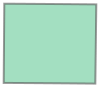

In [ ]:
# Load JSON feature
json_file = proj_path + 'ARD_QQ_SHNF_.geojson'
# Define AOI
aoi = sliderule.toregion(json_file)['poly']
# Plot
gpd.GeoDataFrame.from_file(json_file)['geometry'][0]

# Ancillary Data  
# <<<<< Google Earth Engine >>>>>


**Authenticate & Initialize**<br>

*ee_project:* is your Google Earth Engine project ID, which can be found at https://console.cloud.google.com/home/dashboard and https://code.earthengine.google.com/


<br>You might get this error the first time: <br>
**Initialization failed**: Google Earth Engine API has not been used in project XXX before or it is disabled... Try this link or whatever the error tells you do to https://console.developers.google.com/apis/api/earthengine.googleapis.com/overview

<br>You might get this error: <br>
**Initialization failed**: Project XXX is not registered to use Earth Engine... Try this link or whatever the error tells you do to https://code.earthengine.google.com/register and select non-commercial, then answer a few questions.


Again, you **MUST** allow access to your Google Drive.

In [ ]:
# Define Project ID
ee_project = 'lasers-lab-ee-login-01' # This is *MY* Google Earth Engine project ID. You must enter your own GEE project ID.

# Authenticate
try:
    ee.Authenticate()
    print('Google Earth Engine has been authenticated.')
except Exception as e:
    print(f'Authentication failed: {e}')

# Initialize
try:
    ee.Initialize(project=ee_project)
    print('Google Earth Engine has been initialized.')
except Exception as e:
    print(f'Initialization failed: {e}')

Google Earth Engine has been authenticated.
Google Earth Engine has been initialized.


In [ ]:
# Convert AOI to a list of coordinate pairs (for EE ROI)
coordinates = [[point['lon'], point['lat']] for point in aoi]
# Create the polygon geometry
roi = ee.Geometry.Polygon([coordinates])
# Print the geometry to verify
# roi.getInfo()

## 1) NOTE: all GEE exports in this notebook are going to the default directory 'GEE_Exports_temp' located here: <u>content/drive/MyDrive/GEE_Exports_temp</u>
## 2) If you can't or don't want to download everthing right now, a download folder is available for your use: https://drive.google.com/drive/folders/1hoI-HjlC5BjefLIJW_Bt95YV-tNLPCMg
## 3) It will be helpful to open the GEE code editor in another window to monitor the progress in the **Tasks** tab: https://code.earthengine.google.com/


## Landsat via EE
 * [LANDSAT/LC08/C02/T1_L2](https://developers.google.com/earth-engine/datasets/catalog/LANDSAT_LC08_C02_T1_L2)
 * [LANDSAT/LC09/C02/T1_L2](https://developers.google.com/earth-engine/datasets/catalog/LANDSAT_LC09_C02_T1_L2)


In [ ]:
def L89_composite(year, start_month, tot_months, roi):
    '''
    Creates a composite image from Landsat 8 and 9 bands 2-7 (Blue - SWIR2),
    Intended to be used during one calendar year, e.g., during the growing season.

    Inputs:
        year: single calendar year
        start_month: first month of composite
        tot_months: number of months to composite (within same year)
        roi: ee.Geometry.Polygon or similar
    '''

    # 1. Define Parameters
    start_date = ee.Date.fromYMD(year, start_month, 1)
    end_date = start_date.advance(tot_months, 'month')
    end_mo = start_month + tot_months - 1

    L9 = 'LANDSAT/LC09/C02/T1_L2'
    L8 = 'LANDSAT/LC08/C02/T1_L2'

    name = f'L89_{year}_{start_month:02d}-{end_mo:02d}'

    # 2. Cloud Masking and Index Calculation
    def mask_sr_clouds(image):
        qa_pixel = image.select('QA_PIXEL')
        cloud_shadow_bit_mask = (1 << 4)
        cloud_bit_mask = (1 << 3)
        mask = qa_pixel.bitwiseAnd(cloud_shadow_bit_mask).eq(0) \
                      .And(qa_pixel.bitwiseAnd(cloud_bit_mask).eq(0)) \

        optical_bands = image.select('SR_B.').multiply(0.0000275).add(-0.2)
        # (https://developers.google.com/earth-engine/landsat_c1_to_c2)

        return image.addBands(optical_bands, None, True)\
                    .updateMask(mask)

    # 3. Filter, Mask, and Composite
    collection_L8 = ee.ImageCollection(L8).filterBounds(roi).filterDate(start_date, end_date)
    collection_L9 = ee.ImageCollection(L9).filterBounds(roi).filterDate(start_date, end_date)

    merged_collection = collection_L8.merge(collection_L9)
    masked_collection = merged_collection.map(mask_sr_clouds)

    bands_to_composite = ['SR_B2', 'SR_B3', 'SR_B4', 'SR_B5', 'SR_B6', 'SR_B7']
    monthly_composite = masked_collection.select(bands_to_composite).median() \
        .rename([name+'_b', name+'_g', name+'_r', name+'_nir', name+'_swir1', name+'_swir2'])

    # Clip and reproject
    monthly_composite = monthly_composite.clip(roi).reproject(crs='EPSG:4326', scale=30)

    return monthly_composite

In [ ]:
L1 = L89_composite(2022, 4, 3, roi)
L2 = L89_composite(2022, 7, 3, roi)

L89_stack = ee.Image.cat(L1, L2)
L89_stack

In [ ]:
# # Export the raster to Google Drive
# task = ee.batch.Export.image.toDrive(
#     image=L89_stack,
#     description='L89_export',
#     folder='GEE_Exports_temp',
#     region=roi,
#     scale=30,
#     crs='EPSG:4326'
# )
# task.start()

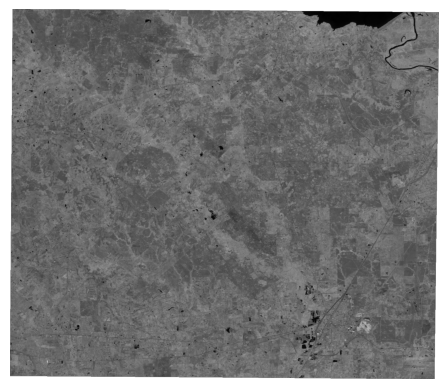

In [ ]:
# Display raster

local_filepath = ee_exports + 'L89_export.tif' # Adjust this path if you move the file
try:
    with rasterio.open(local_filepath) as src:
        # Read the first band
        band = src.read(4)

        # Display the first band
        # plt.figure(figsize=(10, 10))
        plt.imshow(band, cmap='gray') # Use a grayscale colormap for single band
        plt.axis('off')
        plt.show()
except rasterio.errors.RasterioIOError as e:
    print(f"Error opening or reading raster file: {e}")
    print("Please ensure the file has finished exporting and the path is correct.")

## DEM
https://developers.google.com/earth-engine/datasets/catalog/USGS_3DEP_10m_collection

In [ ]:
def fetch_dem(roi, scale=30):
    """
    Loads and processes the USGS 3DEP 10 m DEM dataset for a given ROI.

    Inputs:
        roi: ee.Geometry (e.g., Polygon)
        scale: output resolution in meters (used at export/visualization; default: 30)

    Returns:
        A multiband ee.Image with bands:
            - elev_m (int16): elevation in meters (rounded), masked where DEM is nodata
    """
    # Load and mosaic 3DEP 10 m over ROI
    dem_raw = (
        ee.ImageCollection("USGS/3DEP/10m_collection")  # keep native projection in meters
        .filterBounds(roi)
        .mosaic()
        .clip(roi)
        .reproject(crs="EPSG:4326", scale=scale)
    )

    # Terrain products on native (projected) DEM
    terrain = ee.Terrain.products(dem_raw)

    return dem_raw

In [ ]:
dem = fetch_dem(roi)
dem

In [ ]:
# # Export the raster to Google Drive
# task = ee.batch.Export.image.toDrive(
#     image=dem,
#     description='dem_export',
#     folder='GEE_Exports_temp',
#     region=roi,
#     # scale=30,
#     # crs='EPSG:4326'
# )
# task.start()

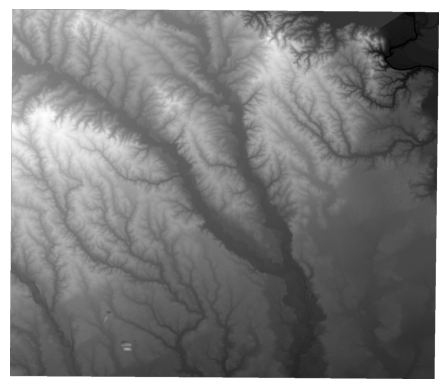

In [ ]:
# Display raster

local_filepath = ee_exports + 'dem_export.tif' # Adjust this path if you move the file
try:
    with rasterio.open(local_filepath) as src:
        # Read the first band
        band = src.read(1)

        # Display the first band
        # plt.figure(figsize=(10, 10))
        plt.imshow(band, cmap='gray') # Use a grayscale colormap for single band
        plt.axis('off')
        plt.show()
except rasterio.errors.RasterioIOError as e:
    print(f"Error opening or reading raster file: {e}")
    print("Please ensure the file has finished exporting and the path is correct.")

## Image stack

In [ ]:
L89 = ee_exports + 'L89_export.tif'
dem = ee_exports + 'dem_export.tif'
full_stack = ee_exports + 'full_stack.tif'

# --- Open input files ---
with rasterio.open(L89) as src_multi, \
     rasterio.open(dem) as src_single:

    # Read all multiband data
    multi_data = src_multi.read()

    # Read single-band data
    single_data = src_single.read(1)

    # --- Check dimensions ---
    if src_multi.shape != src_single.shape:
        raise ValueError("Images must have the same height/width to stack.")

    # --- Prepare metadata ---
    meta = src_multi.meta.copy()
    meta.update(count=src_multi.count + 1)   # Add 1 new band

    # --- Write output ---
    with rasterio.open(full_stack, "w", **meta) as dst:
        # Write original multiband layers
        for i in range(src_multi.count):
            dst.write(multi_data[i], i + 1)

        # Write new single band as the last band
        dst.write(single_data, src_multi.count + 1)

print("Done! Output written to:", full_stack)

Done! Output written to: /content/drive/MyDrive/GEE_Exports_temp/full_stack.tif


In [ ]:
os.listdir(ee_exports)

['dem_export.tif', 'full_stack.tif', 'L89_export.tif']

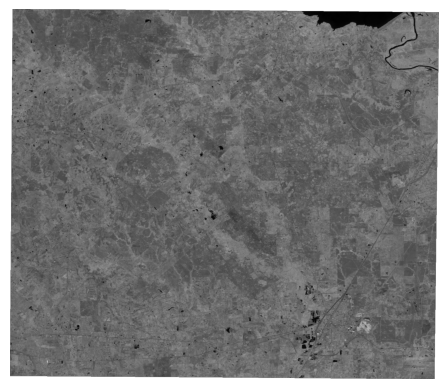

In [ ]:
# Display raster

local_filepath = ee_exports + 'full_stack.tif' # Adjust this path if you move the file
try:
    with rasterio.open(local_filepath) as src:
        # Read the first band
        band = src.read(4)

        # Display the first band
        # plt.figure(figsize=(10, 10))
        plt.imshow(band, cmap='gray') # Use a grayscale colormap for single band
        plt.axis('off')
        plt.show()
except rasterio.errors.RasterioIOError as e:
    print(f"Error opening or reading raster file: {e}")
    print("Please ensure the file has finished exporting and the path is correct.")

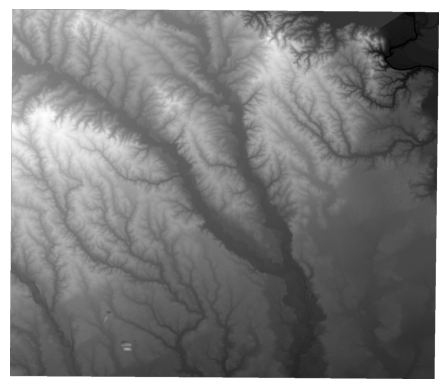

In [ ]:
# Display raster

local_filepath = ee_exports + 'full_stack.tif' # Adjust this path if you move the file
try:
    with rasterio.open(local_filepath) as src:
        # Read the first band
        band = src.read(13)

        # Display the first band
        # plt.figure(figsize=(10, 10))
        plt.imshow(band, cmap='gray') # Use a grayscale colormap for single band
        plt.axis('off')
        plt.show()
except rasterio.errors.RasterioIOError as e:
    print(f"Error opening or reading raster file: {e}")
    print("Please ensure the file has finished exporting and the path is correct.")

In [ ]:
# Capture the full_stack band names
with rasterio.open(L89) as src:
    band_names = list(src.descriptions)
with rasterio.open(dem) as src:
    dem_band = list(src.descriptions)
band_names.extend(dem_band)
band_names

['L89_2022_04-06_b',
 'L89_2022_04-06_g',
 'L89_2022_04-06_r',
 'L89_2022_04-06_nir',
 'L89_2022_04-06_swir1',
 'L89_2022_04-06_swir2',
 'L89_2022_07-09_b',
 'L89_2022_07-09_g',
 'L89_2022_07-09_r',
 'L89_2022_07-09_nir',
 'L89_2022_07-09_swir1',
 'L89_2022_07-09_swir2',
 'elevation']

# "Download" spaceborne lidar from AOI

## ICESat-2 ATL08

In [ ]:
parms = {
    "poly": aoi,
    "t0": '2022-01-01',
    "t1": '2023-01-01',
    "srt": 0,
    "phoreal": {},  # Required for vegetation metrics
}

atl08_gdf = sliderule.run('atl08x', parms)

# Set to WGS84
atl08_gdf = atl08_gdf.set_crs("EPSG:4326", allow_override=True)

print(f'Total records returned: {len(atl08_gdf):,}')
print(atl08_gdf.index.min())
print(atl08_gdf.index.max())
atl08_gdf.head()

Total records returned: 8,397
2022-03-11 10:27:40.389833472
2022-12-24 08:50:47.968309248


,n_te_photons,segment_snowcover,region,gt,h_te_uncertainty,solar_elevation,segment_id_beg,canopy_h_metrics,segment_cover,terrain_slope,...,spot,n_seg_ph,h_canopy_uncertainty,h_max_canopy,h_min_canopy,srcid,segment_landcover,cycle,canopy_openness,geometry
time_ns,,,,,,,,,,,,,,,,,,,,,
2022-08-07 03:19:51.104737792,27,1,2,10,0.470264,-25.272297,168191,"[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...",49,-0.001492,...,6,41,NaN,NaN,NaN,16,126,16,NaN,POINT (-94.99056 30.3217)
2022-08-07 03:19:51.118894848,32,1,2,10,0.397880,-25.271711,168196,"[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...",35,0.001908,...,6,37,NaN,NaN,NaN,16,126,16,NaN,POINT (-94.99066 30.3226)
2022-08-07 03:19:51.132977152,40,1,2,10,0.323411,-25.271099,168201,"[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...",25,0.001786,...,6,44,NaN,NaN,NaN,16,30,16,NaN,POINT (-94.99076 30.3235)
2022-08-07 03:19:51.147028992,33,1,2,10,0.392025,-25.270494,168206,"[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...",25,-0.001239,...,6,38,NaN,NaN,NaN,16,30,16,NaN,POINT (-94.99086 30.3244)
2022-08-07 03:19:51.161172224,48,1,2,10,0.260482,-25.269886,168211,"[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...",24,-0.001463,...,6,53,NaN,NaN,NaN,16,30,16,NaN,POINT (-94.99097 30.3253)


In [ ]:
# Print list of columns in alpha order
np.sort(atl08_gdf.columns)

array(['canopy_h_metrics', 'canopy_openness', 'cycle', 'geometry', 'gt',
       'h_canopy', 'h_canopy_uncertainty', 'h_max_canopy',
       'h_mean_canopy', 'h_min_canopy', 'h_te_median', 'h_te_uncertainty',
       'n_ca_photons', 'n_seg_ph', 'n_te_photons', 'region', 'rgt',
       'segment_cover', 'segment_id_beg', 'segment_landcover',
       'segment_snowcover', 'solar_elevation', 'spot', 'srcid',
       'terrain_slope'], dtype=object)

In [ ]:
# # Remove columns not needed for now
atl08_gdf_ = atl08_gdf.drop(columns=[
       'canopy_h_metrics', 'canopy_openness', 'cycle', 'gt',
       'h_canopy_uncertainty', 'h_max_canopy',
       'h_mean_canopy', 'h_min_canopy', 'h_te_median', 'h_te_uncertainty',
       'n_ca_photons', 'n_seg_ph', 'n_te_photons', 'region', 'rgt',
       'segment_cover', 'segment_id_beg', 'segment_landcover',
       'segment_snowcover', 'solar_elevation', 'spot', 'srcid',
       'terrain_slope'
       ])

atl08_gdf_.head()

,h_canopy,geometry
time_ns,,
2022-08-07 03:19:51.104737792,NaN,POINT (-94.99056 30.3217)
2022-08-07 03:19:51.118894848,NaN,POINT (-94.99066 30.3226)
2022-08-07 03:19:51.132977152,NaN,POINT (-94.99076 30.3235)
2022-08-07 03:19:51.147028992,NaN,POINT (-94.99086 30.3244)
2022-08-07 03:19:51.161172224,NaN,POINT (-94.99097 30.3253)


In [ ]:
# Remove NaN (not a number)
atl08_gdf_ = atl08_gdf_.dropna()
print(f'Total filtered records: {len(atl08_gdf_):,}')

Total filtered records: 7,217


In [ ]:
# Some quick canopy height metrics
hcan = atl08_gdf_['h_canopy']
print(f'min:    {hcan.min():.1f}')
print(f'mean:   {hcan.mean():.1f}')
print(f'median: {hcan.median():.1f}')
print(f'max:    {hcan.max():.1f}')

min:    1.2
mean:   19.8
median: 20.5
max:    44.8


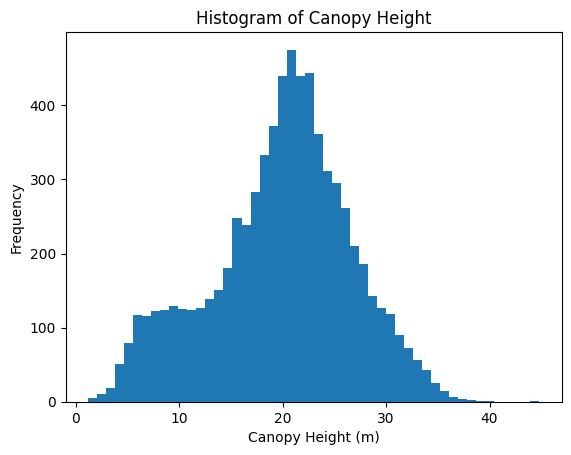

In [ ]:
# Histogram of h_canopy
plt.hist(hcan, bins=50)  # Adjust the number of bins as needed
plt.xlabel('Canopy Height (m)')
plt.ylabel('Frequency')
plt.title('Histogram of Canopy Height')
plt.show()

In [ ]:
# Filter rows to reduce computation time. This method keeps 'gdf' intact during the filtering process.

# Define the percentage of rows to *keep*
percentage = 0.5  # 0.1 keeps 10%
# Randomly sample the DataFrame
reduced_atl08 = atl08_gdf_.sample(frac=percentage, random_state=42)
print(f'Total filtered records: {len(reduced_atl08):,}')

Total filtered records: 3,608


In [ ]:
# # Export to CSV and SHP

# # Add UTC date_time stamp
# timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

# # Save to CSV (preserves date/time field)
# reduced_atl08.to_csv(output + f'ATL08_filtered_points_{timestamp}.csv')

# # Save to ESRI shapefile (only preserves date, removes time)
# with warnings.catch_warnings():
#     warnings.simplefilter("ignore", category=UserWarning)
#     warnings.filterwarnings("ignore", category=UserWarning, module="geopandas")
#     warnings.filterwarnings("ignore", category=RuntimeWarning, module="pyogrio.raw")
#     reduced_atl08.to_file(output + f'ATL08_filtered_points_{timestamp}.shp')

In [ ]:
# os.listdir(output)

## GEDI L2A

In [ ]:
parms = {
    "poly": aoi,
    "t0": '2022-01-01',
    "t1": '2023-01-01',
    "l2_quality_filter": True,
    "anc_fields": ["rh"],
 }

l2ap = gedi.gedi02ap(parms)

# Set to WGS84
l2ap = l2ap.set_crs("EPSG:4326", allow_override=True)

print(f'Total records returned: {len(l2ap):,}')
print(l2ap.index.min())
print(l2ap.index.max())
l2ap.head()

Total records returned: 35,378
2022-01-02 06:34:33.200794624
2022-12-01 03:08:50.208365312


,track,beam,elevation_hr,orbit,elevation_lm,flags,sensitivity,solar_elevation,geometry,rh
time,,,,,,,,,,
2022-01-02 06:34:33.200794624,10543,0,14.185557,17313,11.117723,130,0.913628,-82.303085,POINT (-94.99104 30.29269),"[-3.1, -2.8, -2.54, -2.39, -2.24, -2.13, -2.02..."
2022-02-09 15:26:07.644014848,7238,3,77.845802,17908,74.025330,130,0.918581,25.754400,POINT (-95.37921 30.54806),"[-3.63, -3.37, -3.14, -2.95, -2.8, -2.65, -2.5..."
2022-02-09 15:26:07.652280832,7238,3,78.995857,17908,75.175385,130,0.942088,25.754478,POINT (-95.37879 30.54843),"[-4.6, -3.97, -3.55, -3.29, -3.07, -2.88, -2.6..."
2022-02-09 15:26:07.660546816,7238,3,80.307793,17908,76.712051,130,0.920698,25.754557,POINT (-95.37838 30.54881),"[-4.19, -3.82, -3.55, -3.33, -3.14, -2.99, -2...."
2022-02-09 15:26:07.668813056,7238,3,80.883476,17908,77.250282,130,0.967106,25.754637,POINT (-95.37797 30.54918),"[-4.6, -3.85, -3.44, -3.18, -2.95, -2.77, -2.5..."


In [ ]:
# Print list of columns in alpha order
np.sort(l2ap.columns)

array(['beam', 'elevation_hr', 'elevation_lm', 'flags', 'geometry',
       'orbit', 'rh', 'sensitivity', 'solar_elevation', 'track'],
      dtype=object)

In [ ]:
# Assign RH values
l2ap['h_canopy'] = l2ap['rh'].apply(lambda arr: arr[98])

# Remove columns not needed for now
l2ap_ = l2ap.drop(columns=[
    'beam', 'elevation_hr', 'elevation_lm', 'flags',
    'orbit', 'rh',  'sensitivity', 'solar_elevation', 'track'
    ])

l2ap_.head()

,geometry,h_canopy
time,,
2022-01-02 06:34:33.200794624,POINT (-94.99104 30.29269),2.46
2022-02-09 15:26:07.644014848,POINT (-95.37921 30.54806),2.99
2022-02-09 15:26:07.652280832,POINT (-95.37879 30.54843),2.77
2022-02-09 15:26:07.660546816,POINT (-95.37838 30.54881),2.69
2022-02-09 15:26:07.668813056,POINT (-95.37797 30.54918),2.54


In [ ]:
# Remove NaN (not a number)
l2ap_ = l2ap_.dropna()
print(f'Total filtered records: {len(l2ap_):,}')

Total filtered records: 35,378


In [ ]:
# Some quick canopy height metrics
hcan = l2ap_['h_canopy']
print(f'min:    {hcan.min():.1f}')
print(f'mean:   {hcan.mean():.1f}')
print(f'median: {hcan.median():.1f}')
print(f'max:    {hcan.max():.1f}')

min:    1.9
mean:   18.4
median: 20.1
max:    47.5


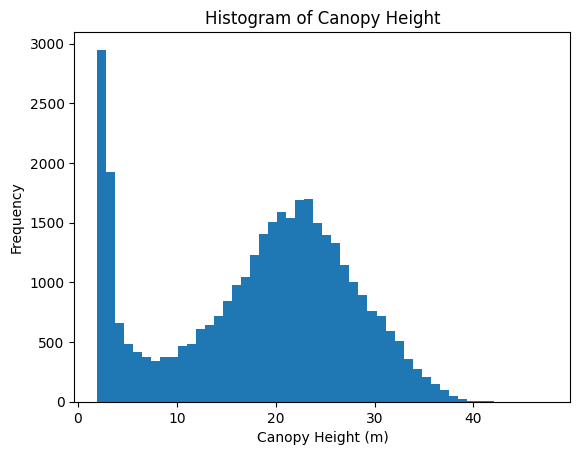

In [ ]:
# Histogram of h_canopy
plt.hist(hcan, bins=50)  # Adjust the number of bins as needed
plt.xlabel('Canopy Height (m)')
plt.ylabel('Frequency')
plt.title('Histogram of Canopy Height')
plt.show()

In [ ]:
# Filter rows to reduce computation time. This method keeps 'gdf' intact during the filtering process.

# Define the percentage of rows to *keep*
percentage = 0.1  # 0.1 keeps 10%

# Randomly sample the DataFrame
reduced_l2ap = l2ap_.sample(frac=percentage, random_state=42)
print(f'Total filtered records: {len(reduced_l2ap):,}')

Total filtered records: 3,538


In [ ]:
# # Export to CSV and SHP

# # Add UTC date_time stamp
# timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

# # Save to CSV (preserves date/time field)
# reduced_l2ap.to_csv(output + f'GEDI_L2A_filtered_points_{timestamp}.csv')

# # Save to ESRI shapefile (only preserves date, removes time)
# with warnings.catch_warnings():
#     warnings.simplefilter("ignore", category=UserWarning)
#     warnings.filterwarnings("ignore", category=UserWarning, module="geopandas")
#     warnings.filterwarnings("ignore", category=RuntimeWarning, module="pyogrio.raw")
#     reduced_l2ap.to_file(output + f'GEDI_L2A_filtered_points_{timestamp}.shp')

In [ ]:
# os.listdir(output)

# Regression

## Combine GDFs

In [ ]:
# Reminder of total number of records in each gdf
print(f'Total records (ATL08): {len(reduced_atl08)}')
print(f'Total records   (L2A): {len(reduced_l2ap)}')

Total records (ATL08): 3608
Total records   (L2A): 3538


In [ ]:
# Combine both to a single gdf
# Removes date/time index, keeps h_canopy and geometry
reduced_combo = pd.concat([reduced_atl08, reduced_l2ap]).reset_index(drop=True)
reduced_combo = gpd.GeoDataFrame(reduced_combo, geometry='geometry')
print(f'Total records in combined GeoDataFrame: {len(reduced_combo):,}')
reduced_combo.head()

Total records in combined GeoDataFrame: 7,146


,h_canopy,geometry
0,17.364805,POINT (-95.01413 30.53964)
1,17.287308,POINT (-95.0222 30.61166)
2,17.469164,POINT (-95.11012 30.3326)
3,22.084480,POINT (-95.34348 30.45656)
4,23.582344,POINT (-95.0078 30.48383)


In [ ]:
reduced_combo = reduced_combo.sample(n=1000, random_state=42)
print(f'Total records in combined GeoDataFrame: {len(reduced_combo):,}')

Total records in combined GeoDataFrame: 1,000


In [ ]:
# Some quick canopy height metrics
hcan = reduced_combo['h_canopy']
print(f'min:    {hcan.min():.1f}')
print(f'mean:   {hcan.mean():.1f}')
print(f'median: {hcan.median():.1f}')
print(f'max:    {hcan.max():.1f}')

min:    2.4
mean:   19.4
median: 20.5
max:    37.7


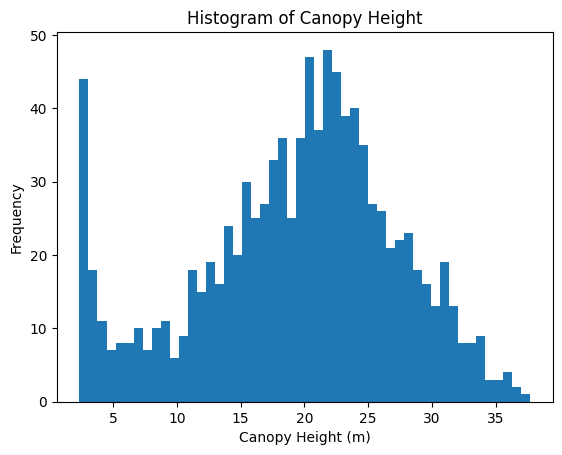

In [ ]:
# Histogram of h_canopy
plt.hist(hcan, bins=50)  # Adjust the number of bins as needed
plt.xlabel('Canopy Height (m)')
plt.ylabel('Frequency')
plt.title('Histogram of Canopy Height')
plt.show()

## Sample layer stack (toothpicks through the sandwich)

In [ ]:
# Sample full_stack and add values to the gdf
with rasterio.open(full_stack) as src:
    band_count = src.count

for b in range(1, band_count + 1):
    reduced_combo[f"band_{b}"] = point_query(
        reduced_combo.geometry,
        full_stack,
        band=b,
        interpolate="nearest",
        nodata=-9999
    )

reduced_combo.head()

,h_canopy,geometry,band_1,band_2,band_3,band_4,band_5,band_6,band_7,band_8,band_9,band_10,band_11,band_12,band_13
4830,21.540001,POINT (-95.28331 30.30813),0.017525,0.040845,0.024262,0.347470,0.139405,0.052065,0.017649,0.043911,0.025775,0.354262,0.145565,0.051914,49.925808
2698,27.835384,POINT (-95.11649 30.40891),0.020990,0.038975,0.023712,0.300885,0.136022,0.053522,0.015875,0.037339,0.021980,0.283161,0.126274,0.047528,57.071293
5143,8.680000,POINT (-95.25494 30.51389),0.022736,0.048655,0.027040,0.388981,0.165929,0.065925,0.021897,0.048132,0.027700,0.372935,0.169710,0.065485,62.109215
1634,22.879061,POINT (-95.03225 30.42708),0.016920,0.036610,0.022283,0.312545,0.129120,0.050305,0.015187,0.039332,0.024400,0.317138,0.129642,0.048710,51.753117
179,22.048386,POINT (-94.99622 30.46875),0.046180,0.074890,0.074560,0.351650,0.245005,0.139653,0.044475,0.073845,0.072443,0.307733,0.239368,0.141000,42.740082


In [ ]:
# Rename columns to match band names
rename_map = {
    f"band_{i+1}": band_names[i]
    for i in range(len(band_names))
}

reduced_combo = reduced_combo.rename(columns=rename_map)
reduced_combo.head()

,h_canopy,geometry,L89_2022_04-06_b,L89_2022_04-06_g,L89_2022_04-06_r,L89_2022_04-06_nir,L89_2022_04-06_swir1,L89_2022_04-06_swir2,L89_2022_07-09_b,L89_2022_07-09_g,L89_2022_07-09_r,L89_2022_07-09_nir,L89_2022_07-09_swir1,L89_2022_07-09_swir2,elevation
4830,21.540001,POINT (-95.28331 30.30813),0.017525,0.040845,0.024262,0.347470,0.139405,0.052065,0.017649,0.043911,0.025775,0.354262,0.145565,0.051914,49.925808
2698,27.835384,POINT (-95.11649 30.40891),0.020990,0.038975,0.023712,0.300885,0.136022,0.053522,0.015875,0.037339,0.021980,0.283161,0.126274,0.047528,57.071293
5143,8.680000,POINT (-95.25494 30.51389),0.022736,0.048655,0.027040,0.388981,0.165929,0.065925,0.021897,0.048132,0.027700,0.372935,0.169710,0.065485,62.109215
1634,22.879061,POINT (-95.03225 30.42708),0.016920,0.036610,0.022283,0.312545,0.129120,0.050305,0.015187,0.039332,0.024400,0.317138,0.129642,0.048710,51.753117
179,22.048386,POINT (-94.99622 30.46875),0.046180,0.074890,0.074560,0.351650,0.245005,0.139653,0.044475,0.073845,0.072443,0.307733,0.239368,0.141000,42.740082


## scikit-learn RF model

In [ ]:
# Display column names
reduced_combo.columns

Index(['h_canopy', 'geometry', 'L89_2022_04-06_b', 'L89_2022_04-06_g',
       'L89_2022_04-06_r', 'L89_2022_04-06_nir', 'L89_2022_04-06_swir1',
       'L89_2022_04-06_swir2', 'L89_2022_07-09_b', 'L89_2022_07-09_g',
       'L89_2022_07-09_r', 'L89_2022_07-09_nir', 'L89_2022_07-09_swir1',
       'L89_2022_07-09_swir2', 'elevation'],
      dtype='object')

In [ ]:
# Define predictors and target
features = reduced_combo[[
    'L89_2022_04-06_b', 'L89_2022_04-06_g',
    'L89_2022_04-06_r', 'L89_2022_04-06_nir', 'L89_2022_04-06_swir1',
    'L89_2022_04-06_swir2', 'L89_2022_07-09_b', 'L89_2022_07-09_g',
    'L89_2022_07-09_r', 'L89_2022_07-09_nir', 'L89_2022_07-09_swir1',
    'L89_2022_07-09_swir2', 'elevation'
    ]]  # Exclude 'geometry'
targets = reduced_combo[['h_canopy']]

In [ ]:
# Train RF model, return metrics and VI table
x = features
y = targets
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size = 0.2, shuffle = True, random_state=42)

model = RandomForestRegressor(random_state=42)
model.fit(x_train, y_train.values.ravel())

y_pred = model.predict(x_test)

print(f'Mean Absolute Error: {mean_absolute_error(y_test, y_pred):.4f}')
print(f'R2 score: {r2_score(y_test, y_pred):.4f}\n')

feat_labels = features.columns
importances = model.feature_importances_
indices = np.argsort(importances)[::-1]

# Store the output in a DataFrame
feature_importance_df = pd.DataFrame({
    'Feature': feat_labels[indices],
    'Importance': importances[indices]
})

print(feature_importance_df)

Mean Absolute Error: 5.2838
R2 score: 0.3609

                 Feature  Importance
0       L89_2022_07-09_r    0.195079
1   L89_2022_07-09_swir1    0.094868
2     L89_2022_07-09_nir    0.084522
3   L89_2022_07-09_swir2    0.072169
4       L89_2022_04-06_b    0.069692
5       L89_2022_07-09_g    0.068291
6     L89_2022_04-06_nir    0.064673
7       L89_2022_04-06_g    0.064352
8       L89_2022_04-06_r    0.063882
9              elevation    0.063751
10  L89_2022_04-06_swir2    0.060642
11  L89_2022_04-06_swir1    0.049919
12      L89_2022_07-09_b    0.048160


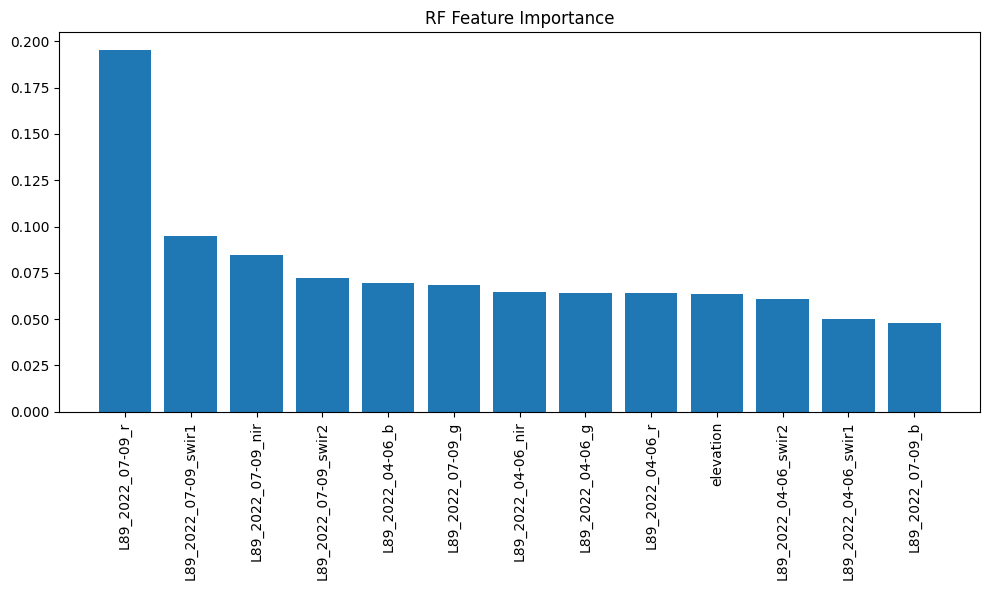

In [ ]:
# Plot VI chart
plt.figure(figsize=(10, 6))
plt.title(f'RF Feature Importance')
plt.bar(range(features.shape[1]), importances[indices], align='center')
plt.xticks(range(features.shape[1]), features.columns[indices], rotation = 90)
plt.xlim([-1, features.shape[1]])
plt.tight_layout()
plt.show()

In [ ]:
# Save RF model for future use

model_package = {
    "model": model,
    "band_names": band_names,
    "feature_order": band_names,
    "scaler": None  # if used, else None
}

joblib.dump(model_package, output + "rf_model.joblib")

['/content/drive/MyDrive/Colab Notebooks/output/rf_model.joblib']

## apply model to layer stack

In [ ]:
# Load model package, apply to full_stack, and create predicted CHM

mp = joblib.load(output + "rf_model.joblib")
rf = mp["model"]
scaler = mp["scaler"]

in_raster = full_stack
out_raster = output + "pred_chm_v1.tif"

# DISABLE FEATURE-NAME VALIDATION FOR RASTER INFERENCE
rf.feature_names_in_ = None

with rasterio.open(in_raster) as src:
    meta = src.meta.copy()
    meta.update(count=1, dtype="int16")

    with rasterio.open(out_raster, "w", **meta) as dst:
        for ji, window in src.block_windows(1):

            # Read block (bands, h, w)
            block = src.read(window=window)
            n_bands, h, w = block.shape

            # Reshape to (pixels, bands)
            X = block.reshape(n_bands, h*w).T
            X = X.astype("float64")   # match training dtype

            # Apply scaler if present
            if scaler is not None:
                X = scaler.transform(X)

            # Predict with RF
            y_pred = rf.predict(X)

            # Reshape back to raster block
            y_block = y_pred.reshape(h, w).astype("int16")

            # Write block
            dst.write(y_block, 1, window=window)

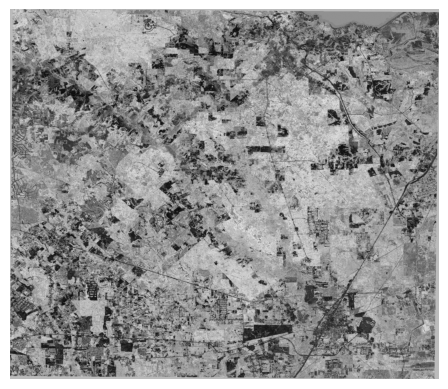

In [ ]:
# Display raster

local_filepath = output + 'pred_chm_v1.tif' # Adjust this path if you move the file
try:
    with rasterio.open(local_filepath) as src:
        # Read the first band
        band = src.read(1)

        # Display the first band
        # plt.figure(figsize=(10, 10))
        plt.imshow(band, cmap='gray') # Use a grayscale colormap for single band
        plt.axis('off')
        plt.show()
except rasterio.errors.RasterioIOError as e:
    print(f"Error opening or reading raster file: {e}")
    print("Please ensure the file has finished exporting and the path is correct.")

## Next steps:
 - Apply to your own study area
 - Add in other important predictor datasets
 - Independently validate against field data or ALS
 - Please cite our notebook in your future work if this was helpful!

# Please complete the workshop evaluation from the link below:

https://docs.google.com/forms/d/e/1FAIpQLSeb-thp9bPUDGuOzyJonwC2HS11HaR52HpaXudyz2UcBrxVrA/viewform?usp=sharing


# Contact

**Justinn J. Jones, MS GISP**

Graduate Research Assistant / FAA sUAS RP

[LASERS Lab](https://lasers.tamu.edu/)

Department of Ecology & Conservation Biology

College of Agriculture & Life Sciences

justinn.j.jones@tamu.edu

**TEXAS A&M UNIVERSITY**

# **Please cite** with this DOI: https://doi.org/10.5281/zenodo.19099501